# Tugas 2 – Deteksi Outlier

Teknik Deteksi Outlier.

1. Mencari data yang ada outlier-nya. (Sertakan sumbernya). (Boleh data Kaggle) <br>
1.5. Jelaskan data tersebut tentang apa. (Termasuk variabelnya apa saja)

2. Kemudian silahkan visualisasi dengan box plot.<br>
2.5 Jelaskan visualisasi box plot-nya.
3. Jelaskan Data Outlier tersebut. (Misal tentang apa, nilai berapa)
4. Dikumpulkan melalui Jupyter Notebook di GitHub, kemudian salin link GitHub ke tugas 2 ini.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# Dataset: BMW Cars Market Dataset (Synthetic)
# Sumber  : https://www.kaggle.com/datasets/
#           (bmw-cars-market-dataset-synthetic)
# ---------------------------------------------------------------

df = pd.read_csv(r"C:\Users\Mareko\OneDrive\Documents\Python Statistika\DataSets\bmw_cars_market_dataset_synthetic.csv")

print(f"Jumlah baris   : {len(df):,}")
print(f"Jumlah kolom   : {df.shape[1]}")
df.head()

Jumlah baris   : 10,000
Jumlah kolom   : 20


,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,white,3.0,no,full,Netherlands
3,4,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,192.0,81594,5,5,suv,blue,1.0,no,NaN,France
4,5,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,204.0,104105,4,5,sedan,white,1.0,no,full,Spain


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  int64  
 1   model                         10000 non-null  str    
 2   year                          10000 non-null  int64  
 3   engine_size                   9757 non-null   float64
 4   horsepower                    10000 non-null  int64  
 5   fuel_type                     10000 non-null  str    
 6   transmission                  9785 non-null   str    
 7   drivetrain                    10000 non-null  str    
 8   mileage_km                    10000 non-null  int64  
 9   fuel_consumption_l_per_100km  9754 non-null   float64
 10  co2_emissions_g_km            9775 non-null   float64
 11  price_usd                     10000 non-null  int64  
 12  doors                         10000 non-null  int64  
 13  seats        

In [4]:
df.describe()

,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count
count,10000.00000,10000.000000,9757.000000,10000.000000,10000.000000,9754.000000,9775.000000,10000.000000,10000.000000,10000.000000,9745.000000
mean,5000.50000,2016.381700,2.484555,269.948600,112364.794000,6.568987,144.105678,50861.398800,4.319900,4.725600,1.943048
std,2886.89568,5.442478,1.201003,80.687398,86335.775989,3.021995,67.019864,31131.966363,0.774741,0.691052,1.378248
min,1.00000,2005.000000,0.000000,120.000000,0.000000,0.000000,0.000000,2640.000000,2.000000,2.000000,0.000000
25%,2500.75000,2012.000000,2.000000,211.000000,39924.000000,5.400000,118.000000,29330.250000,4.000000,5.000000,1.000000
50%,5000.50000,2017.000000,2.600000,260.000000,94483.000000,7.200000,157.000000,44324.000000,4.000000,5.000000,2.000000
75%,7500.25000,2021.000000,3.300000,317.000000,171752.750000,8.700000,191.000000,63835.500000,5.000000,5.000000,3.000000
max,10000.00000,2024.000000,5.000000,700.000000,300000.000000,12.900000,297.000000,225487.000000,5.000000,5.000000,5.000000


### 1. Penjelasan Mengenai Dataset

**Sumber data:** [BMW Cars Market Dataset (Synthetic) – Kaggle](https://www.kaggle.com/datasets)

Dataset ini berisi data pasar mobil BMW yang disimulasikan secara sintetis. Data menggambarkan berbagai faktor yang memengaruhi **harga jual mobil BMW** di beberapa negara. Terdapat **10.000 baris** data dengan **20 variabel (kolom)**.

#### Daftar Variabel

| Kolom | Tipe | Keterangan |
|---|---|---|
| `car_id` | int | ID unik setiap entri mobil |
| `model` | str | Model BMW (mis. X5, 3 Series, i7) |
| `year` | int | Tahun produksi |
| `engine_size` | float | Ukuran mesin dalam liter (0.0 = kendaraan listrik) |
| `horsepower` | int | Tenaga kuda (HP) |
| `fuel_type` | str | Jenis bahan bakar (petrol, diesel, electric, hybrid) |
| `transmission` | str | Jenis transmisi (automatic / manual) |
| `drivetrain` | str | Sistem penggerak (FWD / RWD / AWD) |
| `mileage_km` | int | Jarak tempuh dalam kilometer |
| `fuel_consumption_l_per_100km` | float | Konsumsi BBM (liter per 100 km) |
| `co2_emissions_g_km` | float | Emisi CO₂ (gram per km) |
| `price_usd` | int | Harga jual dalam USD (**variabel target**) |
| `doors` | int | Jumlah pintu |
| `seats` | int | Jumlah kursi |
| `body_type` | str | Tipe bodi (sedan, suv, hatchback, dll.) |
| `color` | str | Warna eksterior |
| `owner_count` | float | Jumlah pemilik sebelumnya |
| `accident_history` | str | Riwayat kecelakaan (yes / no) |
| `service_history` | str | Riwayat servis (full / partial / none) |
| `country_sold` | str | Negara tempat mobil dijual |

In [5]:
# Tampilkan daftar nama kolom secara ringkas
print("Variabel dalam dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Variabel dalam dataset:
   1. car_id
   2. model
   3. year
   4. engine_size
   5. horsepower
   6. fuel_type
   7. transmission
   8. drivetrain
   9. mileage_km
  10. fuel_consumption_l_per_100km
  11. co2_emissions_g_km
  12. price_usd
  13. doors
  14. seats
  15. body_type
  16. color
  17. owner_count
  18. accident_history
  19. service_history
  20. country_sold


### 2. Visualisasi dengan Box Plot

Di bawah ini divisualisasikan distribusi dan box plot untuk lima variabel numerik utama:
`price_usd`, `mileage_km`, `year`, `engine_size`, dan `horsepower`.

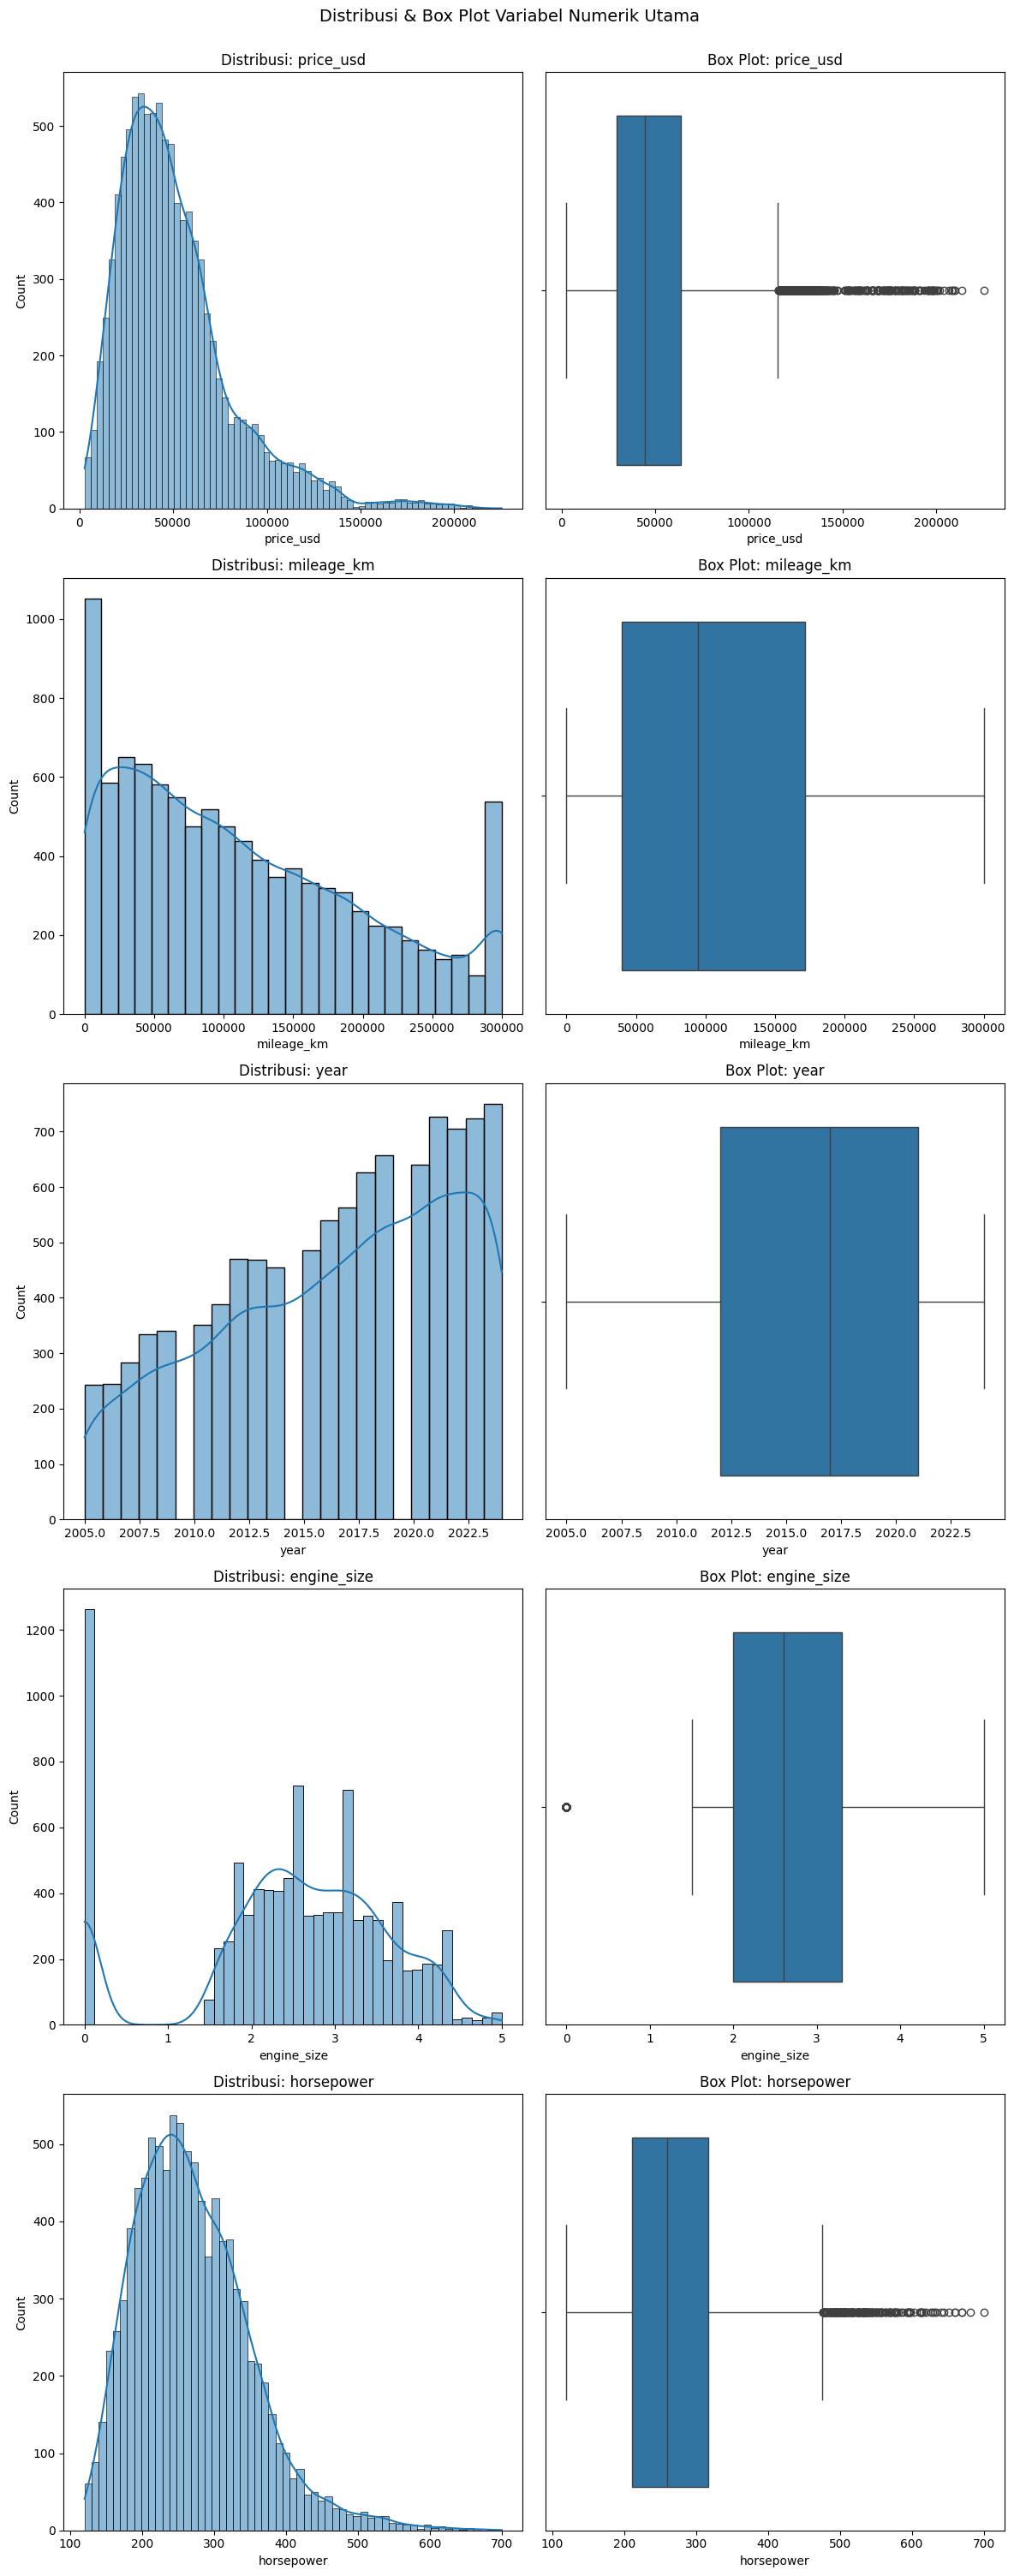

In [6]:
plot_cols = ["price_usd", "mileage_km", "year", "engine_size", "horsepower"]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 6 * len(plot_cols)))
fig.suptitle("Distribusi & Box Plot Variabel Numerik Utama", fontsize=14, y=1.001)

for i, col in enumerate(plot_cols):
    # Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i][0])
    axes[i][0].set_title(f"Distribusi: {col}")
    axes[i][0].set_xlabel(col)

    # Box plot
    sns.boxplot(x=df[col].dropna(), ax=axes[i][1])
    axes[i][1].set_title(f"Box Plot: {col}")
    axes[i][1].set_xlabel(col)

plt.tight_layout()
plt.show()

**2.5 Penjelasan Visualisasi Box Plot**

Berikut ringkasan pengamatan dari setiap box plot:

| Variabel | Pengamatan |
|---|---|
| `price_usd` | Distribusi menjulur ke kanan (*right-skewed*). Terdapat titik-titik di luar whisker yang menunjukkan mobil dengan harga sangat tinggi (outlier atas). |
| `mileage_km` | Distribusi cenderung seragam. Whisker panjang tetapi outlier tidak signifikan. |
| `year` | Distribusi hampir merata antara tahun 2005–2024. Tidak ada outlier yang terlihat. |
| `engine_size` | Terdapat banyak titik di nilai 0.0 (kendaraan listrik). Nilai-nilai ini muncul sebagai outlier bawah karena berbeda jauh dari rata-rata. |
| `horsepower` | Distribusi sedikit menjulur ke kanan. Terdapat beberapa outlier di sisi kanan (HP sangat tinggi). |

### 3. Deteksi & Penjelasan Outlier (Metode IQR)

In [7]:
# Deteksi outlier menggunakan metode IQR (Interquartile Range)
# Batas bawah = Q1 - 1.5 × IQR
# Batas atas  = Q3 + 1.5 × IQR

numeric_cols = ["price_usd", "mileage_km", "year", "engine_size", "horsepower"]

outliers_by_column = {}

for col in numeric_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows = df.loc[mask, ["car_id", "model", "year", col, "mileage_km"]]

    outliers_by_column[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "count": int(mask.sum()),
        "rows": outlier_rows,
    }

print("Deteksi outlier selesai untuk semua kolom.")

Deteksi outlier selesai untuk semua kolom.


In [8]:
# Ringkasan outlier – rapi & mudah dibaca
for col, info in outliers_by_column.items():
    print(f"\n{'='*55}")
    print(f"  Kolom       : {col}")
    print(f"  Batas Bawah : {info['lower_bound']:.2f}")
    print(f"  Batas Atas  : {info['upper_bound']:.2f}")
    print(f"  Jml Outlier : {info['count']:,}")
    if info["count"] > 0:
        print("  Contoh outlier (5 teratas, diurutkan dari nilai terbesar):")
        display(
            info["rows"]
            .sort_values(col, ascending=False)
            .head(5)[["car_id", "model", "year", col]]
        )
    else:
        print("  → Tidak ada outlier yang terdeteksi.")


  Kolom       : price_usd
  Batas Bawah : -22427.62
  Batas Atas  : 115593.38
  Jml Outlier : 462
  Contoh outlier (5 teratas, diurutkan dari nilai terbesar):


,car_id,model,year,price_usd
2958,2959,i7,2024,225487
4222,4223,i7,2023,213851
1878,1879,i7,2021,210181
8767,8768,i7,2024,209567
3953,3954,i7,2021,208614



  Kolom       : mileage_km
  Batas Bawah : -157819.12
  Batas Atas  : 369495.88
  Jml Outlier : 0
  → Tidak ada outlier yang terdeteksi.

  Kolom       : year
  Batas Bawah : 1998.50
  Batas Atas  : 2034.50
  Jml Outlier : 0
  → Tidak ada outlier yang terdeteksi.

  Kolom       : engine_size
  Batas Bawah : 0.05
  Batas Atas  : 5.25
  Jml Outlier : 1,262
  Contoh outlier (5 teratas, diurutkan dari nilai terbesar):


,car_id,model,year,engine_size
9,10,i3,2012,0.0
19,20,i4,2022,0.0
26,27,i4,2010,0.0
35,36,i7,2017,0.0
56,57,i7,2013,0.0



  Kolom       : horsepower
  Batas Bawah : 52.00
  Batas Atas  : 476.00
  Jml Outlier : 201
  Contoh outlier (5 teratas, diurutkan dari nilai terbesar):


,car_id,model,year,horsepower
5374,5375,i7,2021,700
3433,3434,i7,2022,682
8361,8362,i7,2019,670
7549,7550,i7,2015,669
7072,7073,i7,2023,660


**Penjelasan Outlier per Variabel**

#### `price_usd` (Harga dalam USD)
- Outlier berada **di atas batas atas** (sekitar USD 115.000–225.000).
- Didominasi model **BMW i7** dan **7 Series** tahun 2020–2024.
- Masuk akal secara bisnis: model flagship premium memang dijual jauh di atas rata-rata pasar.

#### `mileage_km` (Jarak Tempuh)
- Tidak ada outlier yang terdeteksi secara statistik.
- Rentang data (0–300.000 km) masih dalam batas wajar kendaraan bekas.

#### `year` (Tahun Produksi)
- Tidak ada outlier. Semua tahun berada dalam rentang 2005–2024.

#### `engine_size` (Ukuran Mesin)
- Outlier bawah adalah kendaraan dengan `engine_size = 0.0`, yaitu **kendaraan listrik** (BMW i3, i4, i7).
- Secara teknis ini bukan kesalahan data, melainkan karakteristik kendaraan listrik yang tidak memiliki mesin pembakaran internal.

#### `horsepower` (Tenaga Kuda)
- Outlier berada **di atas batas atas** (> ~476 HP).
- Didominasi model **BMW i7** dan **7 Series** bertenaga tinggi (477–700 HP).
- Merupakan varian sport/M performance yang memang memiliki tenaga jauh di atas rata-rata.

---
**Kesimpulan:** Outlier yang ditemukan sebagian besar mencerminkan segmen **mobil premium atau listrik** dan bukan merupakan kesalahan data. Namun tetap perlu dipertimbangkan saat membangun model prediktif.